In [2]:
import polars as pl 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pl.scan_parquet('/home/ma/a/alb25/Project/thesis_code/data/processed/train_df.parquet')

In [4]:
df.head().collect()

time,source_user@domain,destination_user@domain,source_computer,destination_computer,authentication_type,logon_type,authentication_orientation,source_user_type,destination_user_type,success
duration[μs],str,str,str,str,enum,enum,enum,enum,enum,bool
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C12889""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
6d 8h 13m 45s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
12d 8h 33m 10s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1""","""C1""","""?""","""Network""","""LogOff""","""anon""","""anon""",true
16d 13h 57m 28s,"""ANONYMOUS LOGON@C1""","""ANONYMOUS LOGON@C1""","""C1191""","""C1""","""NTLM""","""Network""","""LogOn""","""anon""","""anon""",true


### Consider / Remove Success failure

In [7]:
success_fail = df.group_by(['source_user@domain', 'success']).len().collect()

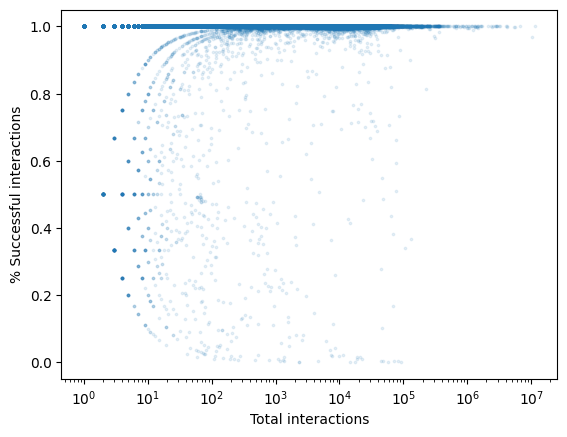

In [ ]:
# Success pct vs number of interactions note the shape comes from the fact that for smaller number of interactions the pct can only take a dsicrete set of values 
# Giving the curved shape
success_counts = success_fail.with_columns(
        pl.col('len').sum().over('source_user@domain').alias('total_inter'),
        (pl.col('len') / pl.col('total_inter')).alias('pct_of_total')).filter(pl.col('success') == True)

plt.scatter(success_counts['total_inter'], success_counts['pct_of_total'], s = 3, alpha=0.1)

plt.xscale('log')
plt.xlabel('Total interactions')
plt.ylabel('% Successful interactions')
plt.show()

In [25]:
success_counts.shape

(61961, 5)

In [ ]:
# Almost all users have over 95% successful interactions
# Failures are a small band making up 5% of interactions in most cases making up a stable prop of auth volume
success_counts.filter(pl.col('pct_of_total') < 0.95)

source_user@domain,success,len,total_inter,pct_of_total
str,bool,u32,u32,f64
"""U194@C2936""",true,6,8,0.75
"""U294@C24586""",true,1,2,0.5
"""C21825$@DOM1""",true,174,660,0.263636
"""U11640@DOM1""",true,2,8,0.25
"""U1718@C22727""",true,3,6,0.5
…,…,…,…,…
"""U1718@C473""",true,2,5,0.4
"""SYSTEM@DOM1""",true,1,2,0.5
"""U11126@C2637""",true,1,2,0.5


## Auth frequency by user and user group

In [5]:
auth_history = df.select(['time', 'source_user@domain']).collect()
frequencies = auth_history.group_by('source_user@domain').len().get_column('len').to_list()

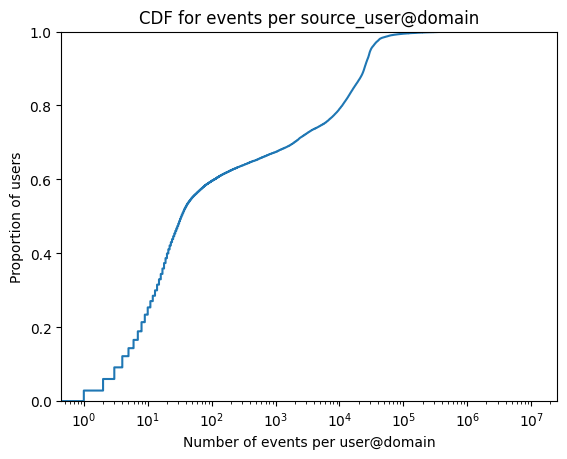

In [10]:
sns.ecdfplot(frequencies)
plt.xlabel('Number of events per user@domain')
plt.ylabel('Proportion of users')
plt.title('CDF for events per source_user@domain')
plt.xscale('log')
plt.show()

### Filteration Concequences

In [ ]:
# Testing what proportion of users have more than 50 events
sum([f for f in frequencies if f > 50]) /sum(frequencies)

0.9990128943210728

Considering splitting up auth events and having a different model for different event types

In [20]:
user_types = df.group_by('source_user_type').len().collect()
user_types

source_user_type,len
enum,u32
"""machine""",387847322
"""system""",9096888
"""anon""",21737383
"""human""",212387616


In [ ]:
total_interactions = user_types.select('len').sum().get_column('len')[0]
system_interactions = user_types.filter(pl.col('source_user_type') == 'system').get_column('len')[0]
system_interactions/total_interactions

0.014415040173509718

#### Other decisions

In [23]:
# Number of authentication 
df.select('authentication_type').group_by('authentication_type').len().collect().sort(by='len')

authentication_type,len
enum,u32
"""TivoliAP""",1
"""N""",1
"""CygwinLsa""",12
"""MICROSOFT_AUTHENTICAT""",13
"""ACRONIS_RELOGON_AUTHENTICATION…",20
…,…
"""MICROSOFT_AUTHENTICATION_PACKA…",528752
"""Negotiate""",15130000
"""NTLM""",31011588


# Notes

- Interval width has its own 'smoothing effect'